# Разведочный анализ данных (Explanatory Data Analysis, EDA) в Python

#### Зачем нужен разведочный анализ как первый этап решения задачи машинного обучения:
- Понимание структуры, распределений и особенностей данных
- Выявление аномалий, ошибок и пропусков
- Выявление взаимосвязей между признаками
- Выбор признаков
- Понимание необходимости порождения новых признаков на основе существующих (feature engeneering)



#### Полезные ссылки:
- <a href="https://pandas.pydata.org/">Документация Pandas</a>
- <a href="https://matplotlib.org/">Документация Matplotlib</a>
- <a href="https://seaborn.pydata.org/">Документация Seaborn</a>

#### Дополнительные материалы:

- Маккинни У. Python и анализ данных / Пер. с англ. Слинкин А.А. – М: ДМК Пресс, 2015. – 482 с. ([Google Books]
- Брюс П., Брюс Э. Практическая статистика для специалистов Data Science. – БХВ-Петербург, 2018. — 304 с. ([Google Books](https://books.google.ru/books?hl=ru&lr=&id=l_6MDwAAQBAJ&oi=fnd&pg=PA5&dq=%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F+%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0+%D0%B4%D0%BB%D1%8F+%D1%81%D0%BF%D0%B5%D1%86%D0%B8%D0%B0%D0%BB%D0%B8%D1%81%D1%82%D0%BE%D0%B2+data+science&ots=fB2sdc0NnS&sig=S7_kC8Nv2Ipg5By2UbTDVDGVvqE&redir_esc=y#v=onepage&q=%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F%20%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0%20%D0%B4%D0%BB%D1%8F%20%D1%81%D0%BF%D0%B5%D1%86%D0%B8%D0%B0%D0%BB%D0%B8%D1%81%D1%82%D0%BE%D0%B2%20data%20science&f=false))
- [Лекции с YouTube](https://www.youtube.com/watch?v=Yhrp-YVZH84)
- [Еще лекции с YouTube](https://youtu.be/uJpDzHGUamg?si=29xzZdo2AzE12nOH)


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


## Загружаем данные

Будем работать с данными метеостанции Малые Кармакулы, взятыми из [архива ВНИИГМИ-МЦД](http://meteo.ru/data/)

In [2]:
data_path = 'EDA_demo_data/wr282025.txt'
fields_path = 'EDA_demo_data/fld282025a0.txt'

# Загружаем информацию о полях из файла данных ВНИИГМИ-МЦД c фиксированной шириной колонок
df_fields = pd.read_fwf (fields_path, encoding = "cp1251", header = None)

display (df_fields)


,0,1,2,3
0,1,1,5,Синоптический индекс станции
1,2,2,4,Год по Гринвичу
2,3,3,2,Месяц по Гринвичу
3,4,4,2,День по Гринвичу
4,5,5,2,Срок по Гринвичу
5,6,6,2,Общее количество облачности
6,7,7,2,Количество облачности нижнего яруса
7,8,8,3,Направление ветра
8,9,9,2,Средняя скорость ветра
9,10,10,2,Максимальная скорость ветра


In [3]:

df_fields[3] = [' '.join(field.split()) for field in df_fields[3]]
display (df_fields[3])


0               Синоптический индекс станции
1                            Год по Гринвичу
2                          Месяц по Гринвичу
3                           День по Гринвичу
4                           Срок по Гринвичу
5                Общее количество облачности
6        Количество облачности нижнего яруса
7                          Направление ветра
8                     Средняя скорость ветра
9                Максимальная скорость ветра
10                             Сумма осадков
11             Температура поверхности почвы
12     Температура воздуха по сухому терм-ру
13           Относительная влажность воздуха
14                    Температура точки росы
15    Атмосферное давление на уровне станции
16       Атмосферное давление на уровне моря
Name: 3, dtype: object

In [4]:
df = pd.read_csv (data_path, sep=';', header=None, names=df_fields[3])
df.head()


,Синоптический индекс станции,Год по Гринвичу,Месяц по Гринвичу,День по Гринвичу,Срок по Гринвичу,Общее количество облачности,Количество облачности нижнего яруса,Направление ветра,Средняя скорость ветра,Максимальная скорость ветра,Сумма осадков,Температура поверхности почвы,Температура воздуха по сухому терм-ру,Относительная влажность воздуха,Температура точки росы,Атмосферное давление на уровне станции,Атмосферное давление на уровне моря
0,20744,1966,12,31,18,,,,,,,,,,,,
1,20744,1966,12,31,21,10,10,180,12,,,,-7.3,97,-8.0,1012.7,1014.8
2,20744,1967,1,1,0,,,,,,,,,,,,
3,20744,1967,1,1,3,10,10,180,9,,0.0,,-7.6,90,-9.0,1010.2,1012.3
4,20744,1967,1,1,6,,,,,,,,,,,,


#### Подготовка данных 

In [5]:
df['datetime'] = [pd.Timestamp(year,month,day,hour) for year,month,day,hour in zip(df['Год по Гринвичу'], df['Месяц по Гринвичу'], df['День по Гринвичу'], df['Срок по Гринвичу'])]

df = df.drop (columns=[x for x in df.columns if 'по Гринвичу' in x or 'Синоптический индекс' in x])

df = df.set_index ('datetime')

new_columns = {'Общее количество облачности': 'tcc', 
               'Количество облачности нижнего яруса': 'lcc', 
               'Направление ветра': 'wdir', 
               'Средняя скорость ветра': 'wvel', 
               'Максимальная скорость ветра': 'wgust',
               'Сумма осадков': 'prec', 
               'Температура поверхности почвы': 'tg', 
               'Температура воздуха по сухому терм-ру': 'ta', 
               'Относительная влажность воздуха': 'rh', 
               'Температура точки росы': 'td', 
               'Атмосферное давление на уровне станции': 'ps', 
               'Атмосферное давление на уровне моря': 'psl'}

df = df.rename(columns=new_columns)
display(df.head())


,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
datetime,,,,,,,,,,,,
1966-12-31 18:00:00,,,,,,,,,,,,
1966-12-31 21:00:00,10,10,180,12,,,,-7.3,97,-8.0,1012.7,1014.8
1967-01-01 00:00:00,,,,,,,,,,,,
1967-01-01 03:00:00,10,10,180,9,,0.0,,-7.6,90,-9.0,1010.2,1012.3
1967-01-01 06:00:00,,,,,,,,,,,,


### Изучим типы данных

In [6]:
display(df.info())



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 163632 entries, 1966-12-31 18:00:00 to 2022-12-31 15:00:00
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   tcc     163632 non-null  object
 1   lcc     163632 non-null  object
 2   wdir    163632 non-null  object
 3   wvel    163632 non-null  object
 4   wgust   163632 non-null  object
 5   prec    163632 non-null  object
 6   tg      163632 non-null  object
 7   ta      163632 non-null  object
 8   rh      163632 non-null  object
 9   td      163632 non-null  object
 10  ps      163632 non-null  object
 11  psl     163632 non-null  object
dtypes: object(12)
memory usage: 16.2+ MB


None

In [7]:
# Преобразуем текстовые значения в числовые
df = df.apply(pd.to_numeric, errors='coerce')
display(df.info())

# Сохраним результаты в новый csv-файл
df.to_csv('EDA_demo_data/karmakuly.csv')


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 163632 entries, 1966-12-31 18:00:00 to 2022-12-31 15:00:00
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   tcc     144599 non-null  float64
 1   lcc     144600 non-null  float64
 2   wdir    144616 non-null  float64
 3   wvel    144602 non-null  float64
 4   wgust   128363 non-null  float64
 5   prec    136801 non-null  float64
 6   tg      0 non-null       float64
 7   ta      144562 non-null  float64
 8   rh      144623 non-null  float64
 9   td      144591 non-null  float64
 10  ps      144588 non-null  float64
 11  psl     144421 non-null  float64
dtypes: float64(12)
memory usage: 16.2 MB


None

## Визуализация временных рядов

Посмотрим на скорость ветра для эпизора боры 10–12 Декабря 2006 г. из статьи [(Shestakova and Debolskiy, 2022)](https://www.mdpi.com/2073-4433/13/7/1108)

In [8]:
#%matplotlib inline 
%matplotlib qt
plt.rcParams['figure.dpi'] = 300

plt.figure()
df['09-Dec-2006':'13-Dec-2006'][['wvel', 'wgust']].plot(ax = plt.gca())

plt.figure()
df[['wvel', 'wgust']].plot(ax = plt.gca())
plt.xlim(('09-Dec-2006','13-Dec-2006'))


(323784.0, 323880.0)

Теперь интерактивный график с использованием Plotly

In [9]:
pd.options.plotting.backend = "plotly"

fig = df['2006':'2007'][['wvel', 'wgust']].plot()

fig.update_layout(xaxis_range=['2006-12-09', '2006-12-13'])
fig.show()

pd.options.plotting.backend = "matplotlib"


## Доступ к столбцам и колонкам в DataFrame

In [10]:
# Доступ по индексу
df['2010-01-01 03':'2010-01-01 03']


,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
datetime,,,,,,,,,,,,
2010-01-01 03:00:00,4.0,0.0,130.0,4.0,18.0,0.0,NaN,-14.6,63.0,-19.7,1039.3,1041.2


In [11]:
# Доступ по порядковому номеру
df[445:448]

,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
datetime,,,,,,,,,,,,
1967-02-25 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-25 12:00:00,8.0,0.0,180.0,14.0,NaN,0.0,NaN,-11.0,81.0,-14.0,1008.4,1010.5
1967-02-25 15:00:00,12.0,12.0,230.0,8.0,NaN,0.0,NaN,-8.4,96.0,-9.0,1009.0,1011.1


In [12]:
# Доступ по массиву булевских значений
df[df['wgust'] > 30]

,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
datetime,,,,,,,,,,,,
1976-12-01 06:00:00,3.0,0.0,110.0,27.0,31.0,0.0,NaN,-23.3,85.0,-25.1,1002.3,1004.4
1977-01-26 09:00:00,10.0,0.0,90.0,27.0,32.0,0.0,NaN,-23.5,87.0,-25.3,1025.4,1027.6
1977-01-26 12:00:00,10.0,0.0,90.0,24.0,31.0,0.0,NaN,-23.3,86.0,-25.1,1026.5,1028.7
1977-01-26 15:00:00,10.0,0.0,90.0,26.0,32.0,0.0,NaN,-24.6,88.0,-25.7,1026.8,1029.0
1977-01-29 06:00:00,10.0,0.0,90.0,34.0,37.0,0.0,NaN,-26.0,85.0,-27.7,1024.1,1026.3
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-04-11 03:00:00,10.0,6.0,110.0,26.0,32.0,0.9,NaN,-5.0,88.0,-6.7,1004.5,1006.5
2022-04-11 06:00:00,10.0,4.0,110.0,27.0,38.0,0.0,NaN,-5.8,87.0,-7.6,1004.3,1006.3
2022-04-26 15:00:00,10.0,7.0,110.0,25.0,32.0,0.0,NaN,-9.4,88.0,-11.0,996.1,998.2


In [13]:
# Доступ к колонкам по имени
df[['wdir', 'wvel']].head()

,wdir,wvel
datetime,,
1966-12-31 18:00:00,NaN,NaN
1966-12-31 21:00:00,180.0,12.0
1967-01-01 00:00:00,NaN,NaN
1967-01-01 03:00:00,180.0,9.0
1967-01-01 06:00:00,NaN,NaN


In [14]:
# Одновременная обрезка по колонкам и столбцам

#df.loc['2010-01-01 03']
#df.loc['2010-01-01 03':'2010-01-01 12', ['wdir', 'wvel']]
df.iloc[3333, 4:7]

wgust   NaN
prec    NaN
tg      NaN
Name: 1968-02-21 09:00:00, dtype: float64

## Анализ доступности данных

C:\Users\mvar9\AppData\Local\Temp\ipykernel_9020\1377008820.py:2: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
datetime,,,,,,,,,,,,
1966-11-30,0.500000,0.500000,0.500000,0.500000,1.0,1.000000,1.0,0.500000,0.500000,0.500000,0.500000,0.500000
1966-12-31,0.161290,0.161290,0.169355,0.165323,1.0,0.512097,1.0,0.165323,0.161290,0.165323,0.161290,0.161290
1967-01-31,0.156250,0.156250,0.156250,0.156250,1.0,0.517857,1.0,0.160714,0.156250,0.156250,0.156250,0.156250
1967-02-28,0.137097,0.137097,0.129032,0.137097,1.0,0.504032,1.0,0.133065,0.129032,0.129032,0.133065,0.133065
1967-03-31,0.175000,0.175000,0.133333,0.137500,1.0,0.508333,1.0,0.133333,0.133333,0.141667,0.133333,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-31,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000
2022-08-31,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000
2022-09-30,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


NameError: name 'sys' is not defined

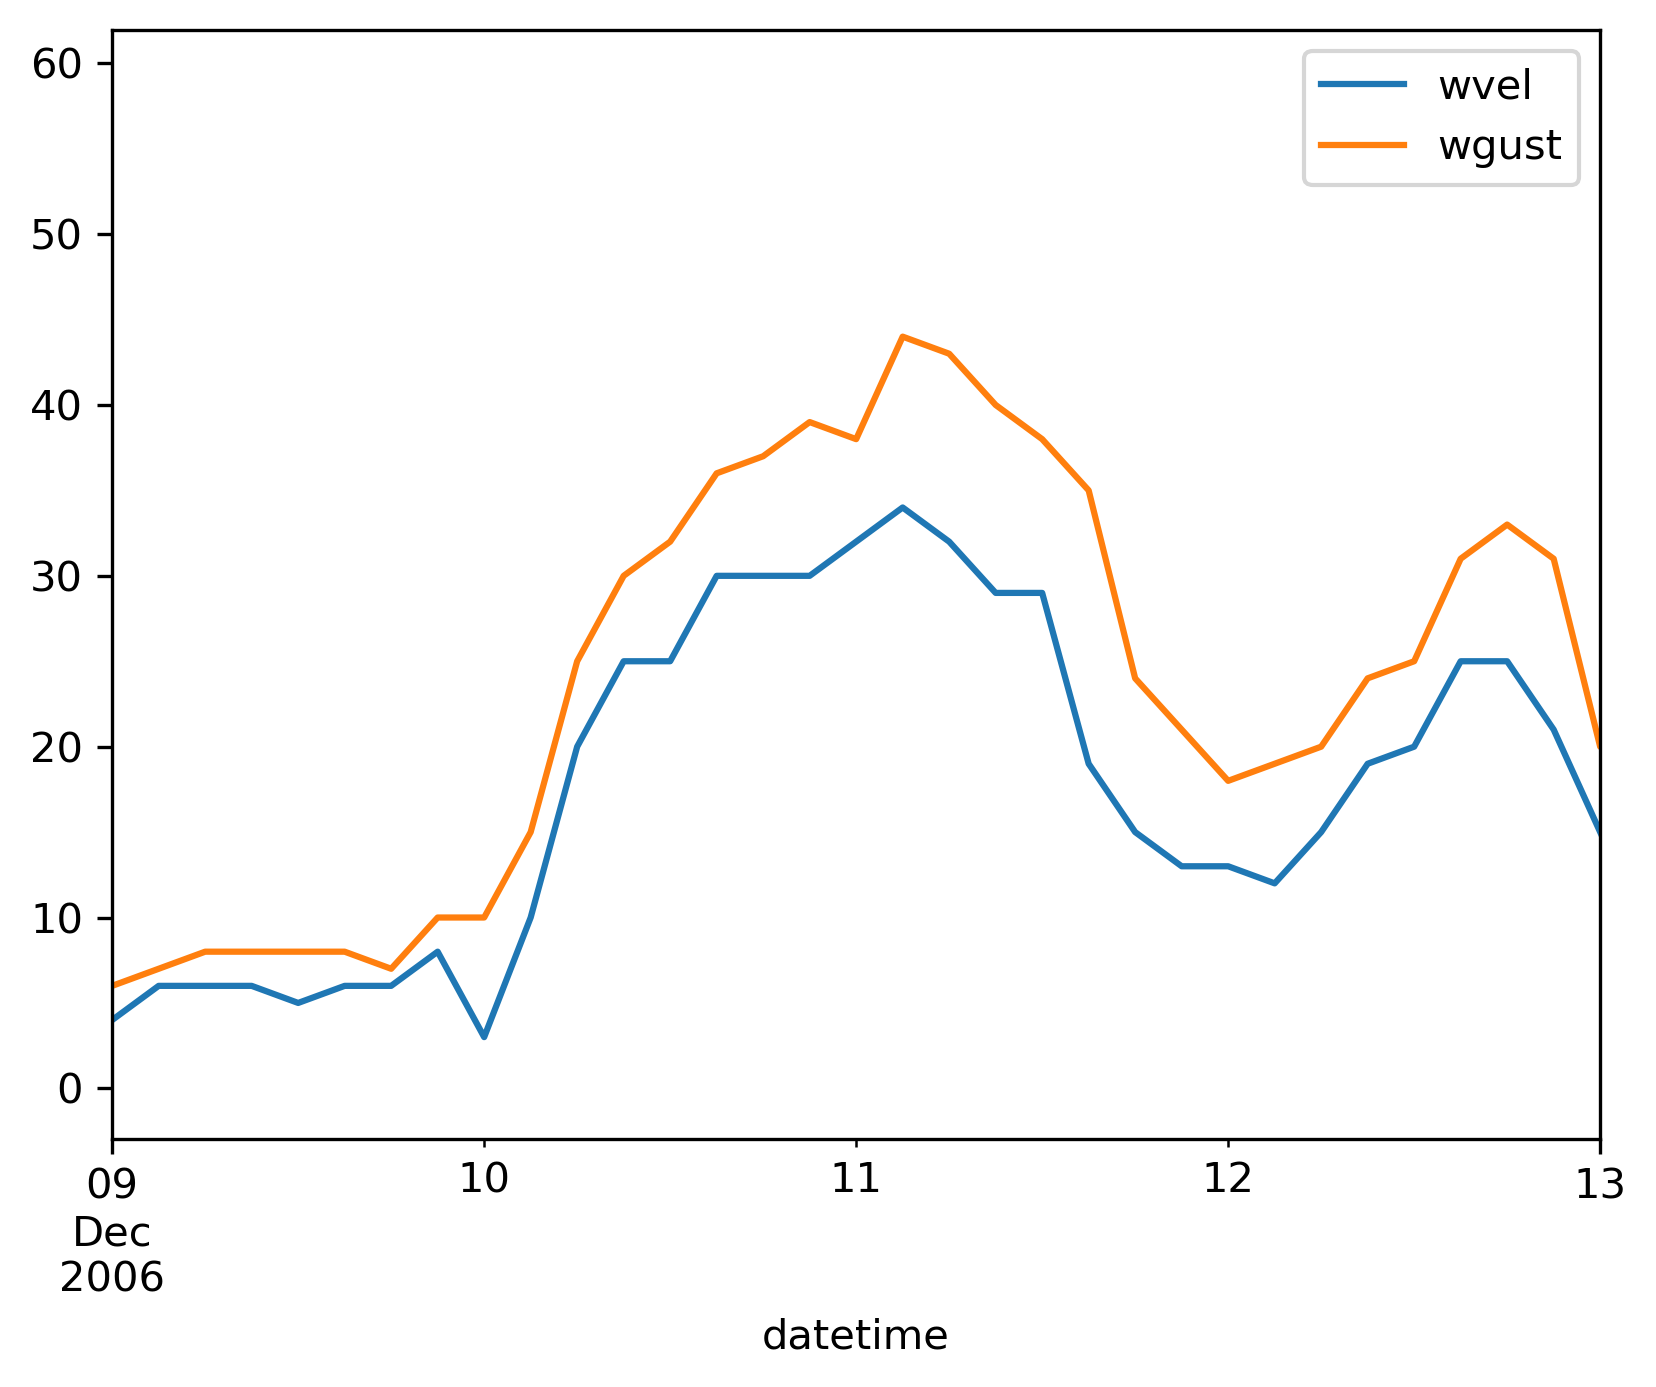

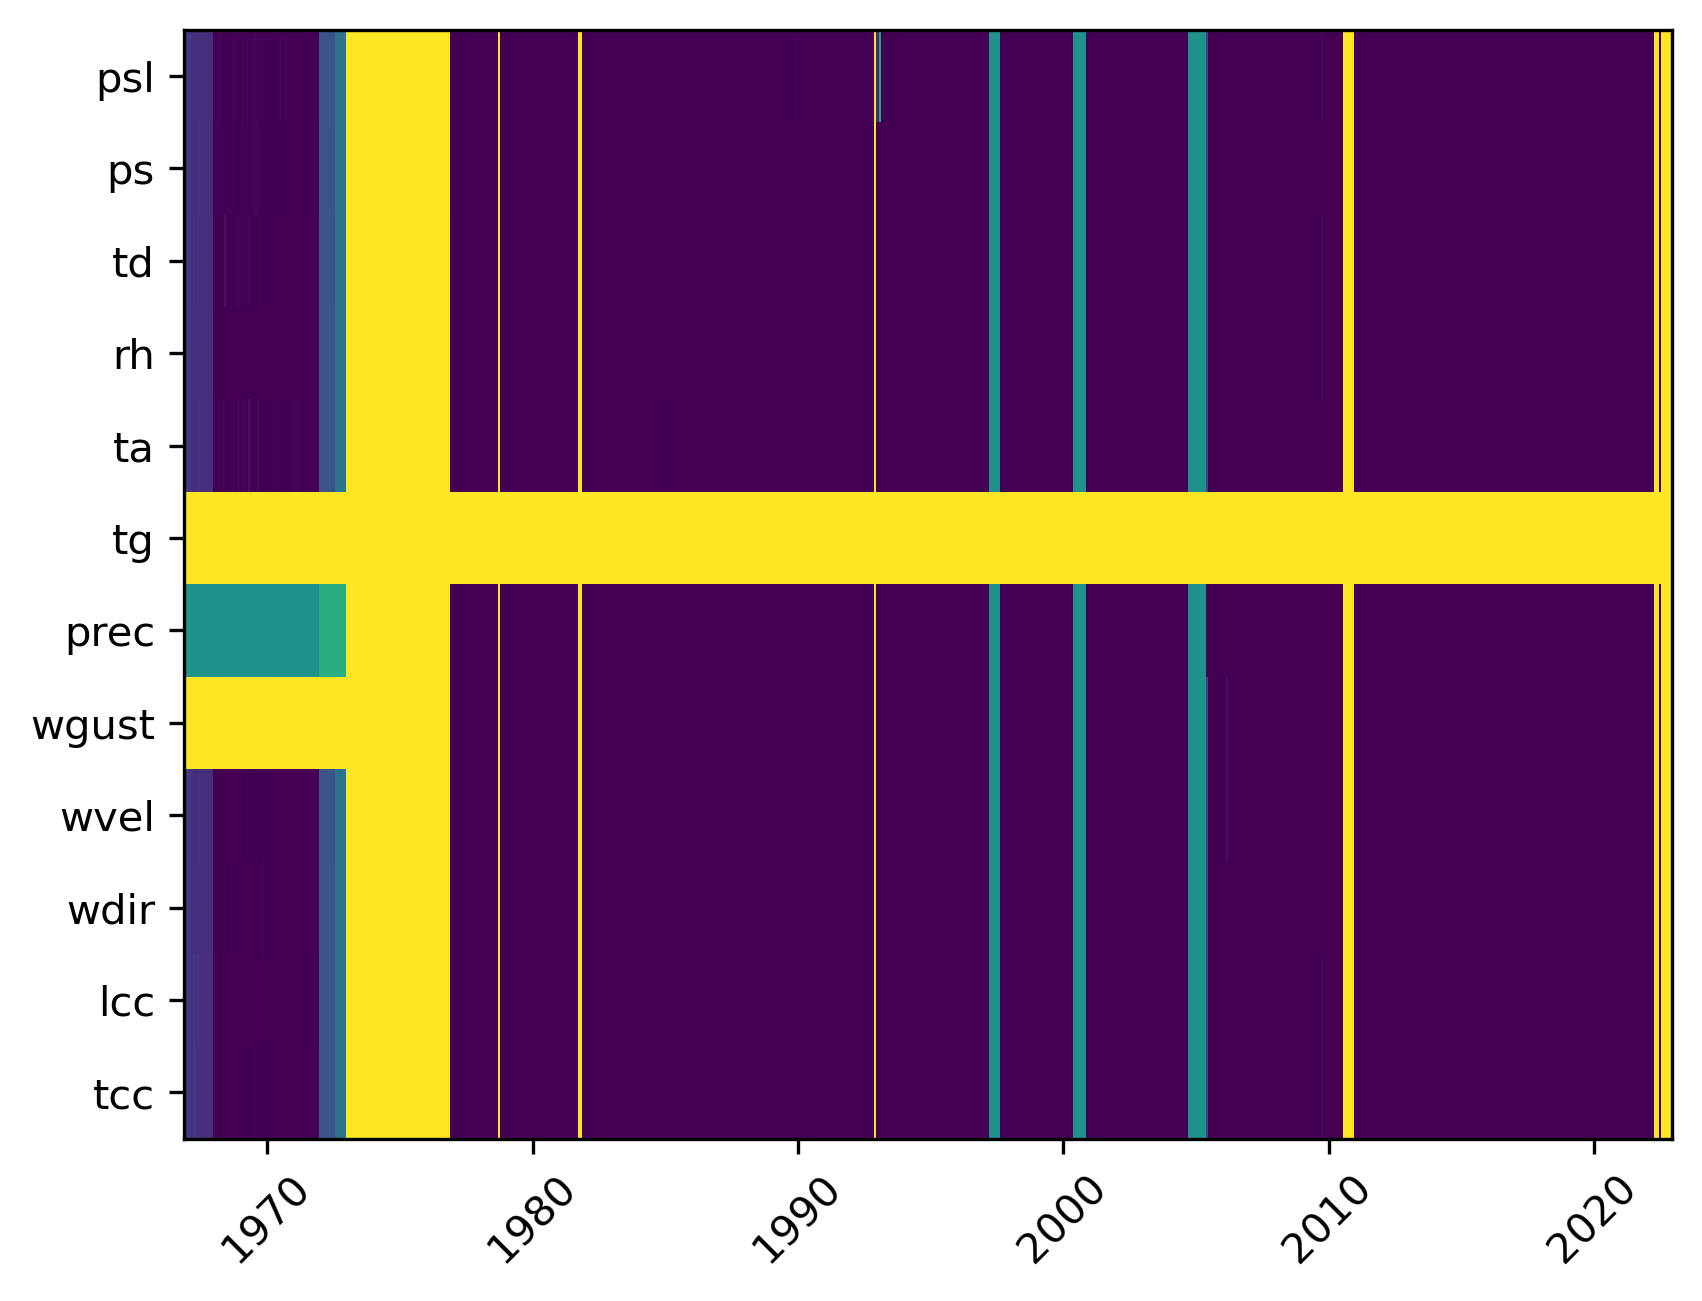

In [ ]:
%matplotlib inline

data_missing = df.isnull ().astype(float).resample('M', label='left').mean()

#display(data_missing)

plt.figure()
plt.pcolormesh(data_missing.index, data_missing.columns, data_missing.T.to_numpy())
_ = plt.xticks(rotation=45)

#sys.exit()


# Одномерный разведочный анализ данных (univariate analysis)

### Анализ статистических моментов 

In [ ]:
#df['wvel'].median()
#df.describe()
df.describe().T #Транспонирование

### Анализ уникальных значений

In [ ]:
nunique = lambda x: len (pd.unique(x))

print ('Уникальные значения в столбцах: ')
display(df.apply (pd.unique))

print ('Число уникальных значений в столбцах:  ')
display(df.nunique())

In [ ]:
# Уникальные значения балла облачности
np.sort (df['tcc'].unique())

In [ ]:
# Подсчет уникальных значений

#df_cr = df['2015':]

display(df['tcc'].value_counts().sort_index())
plt.figure()
df['tcc'].value_counts().sort_index().plot.bar() #
plt.figure()
df['tcc'].value_counts().sort_index().plot.pie() #

### Анализ функций распределения

In [ ]:
#Гистограммы распределения
%matplotlib inline
df.hist(figsize=(20,20), density=True)

### Что с направлением ветра?

In [ ]:
df[df['wdir'] == 999]

In [ ]:
mask_999 = df['wdir'] == 999

# Создаем маски для соседних строк
mask_prev = mask_999.shift(1, fill_value=False)  # предыдущие строки
mask_next = mask_999.shift(-1, fill_value=False)  # следующие строки

# Объединяем все маски
combined_mask = mask_999 | mask_prev | mask_next

result = df[combined_mask]
display(result)

### Графики ядерной плотности (kernel density plots)

Ядерные оценки плотности — KDE, Kernel Density Estimates — способ что-то понять о распределении, когда неизвестно ничего. Такого рода методы называют непараметрическими, они иллюстрируют разницу подходов в статистике и теории вероятностей: если в теории вероятности известно распределение и исследуются его свойства, то в статистике зачастую известны только данные, и по их свойствам угадывается распределение.

Смысл: в каждую точку выборки поставили отмасштабированное ядро так, будто эта точка — центр ядра, а затем усреднили значения соседних точек с весами, заданными этим ядром. Вместо тысячи слов — [интерактивная иллюстрация](https://mathisonian.github.io/kde/).

In [ ]:
#Гистограммы и графики ядерной плотности 

plt.figure()
df[['wvel', 'wgust']].plot.hist(alpha=0.5, density = True, bins=np.arange(-0.5, 40.5))
df[['wvel', 'wgust']].plot.density(ax = plt.gca(), color = ['blue', 'red'], bw_method=0.1) 
plt.xlim(0, 40)


In [ ]:
decades = np.arange(1970, 2010, 10)

for decade_start in decades:
    df4decade = df[str(decade_start) + '-01-01':str(decade_start + 10) + '-12-31']

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    df4decade['wvel'].value_counts(normalize = True).sort_index().plot.bar(ax = plt.gca(), color = 'blue', alpha = 0.5, label = 'wvel')
    plt.xlim(0, 30)
    plt.subplot(1,2,2)
    df4decade['wgust'].value_counts(normalize = True).sort_index().plot.bar(ax = plt.gca(), color= 'red', alpha = 0.5, label = 'wgust')
    plt.suptitle(f'{decade_start} - {decade_start + 10}')
    plt.xlim(0, 30)

### Ищучим динамику повторяемости подозрительных значений во времени

In [ ]:
counts = df.groupby (df.index.year)['wgust'].value_counts(normalize = True)

years = counts.index.get_level_values(0).unique()
vals  = counts.index.get_level_values(1).unique() 

counts = pd.concat([pd.DataFrame (counts[year]).T.reindex(sorted(vals), axis=1) for year in years]).fillna(0)
counts['year'] = years
counts = counts.set_index ('year')
counts.loc[:, 13:15].plot()



### Идентификация выбросов 

In [ ]:
# Ящики с усами
#df.plot.box()
df[['wvel', 'wgust']].plot.box()

In [ ]:
df.plot(kind='box', subplots=True,  figsize=(15, 5))
plt.subplots_adjust(wspace=0.9) 

## Двумерный анализ данных (bivariate data analysis)

#### Корреляция

In [ ]:
corrs = df.corr()

display (corrs)

s = sns.heatmap (corrs, annot=True, annot_kws={'fontsize': 'xx-small'})
#plt.set(s,  fontsize = 'x-small')

### Диаграммы рассеяния

In [ ]:
plt.figure()
#plt.scatter (df['ta'], df['td'])
plt.scatter (df['wvel'], df['wgust'])
y_lim = plt.ylim()
display(y_lim)
plt.plot(y_lim, y_lim, '-k')
plt.gca().set_aspect('equal')

### Шестиугольные корзины

In [ ]:
#plt.hexbin(df['wvel'], df['wgust'], gridsize=50, mincnt = 2)

plt.hexbin(df['ta'], df['td'], gridsize=50, mincnt = 1)
plt.gca().set_aspect('equal')
plt.grid()
# plt.xlim((0, 50))
# plt.ylim((0, 50))

In [ ]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


df['season'] = [month_to_season (m) for m in df.index.month] 

sns.jointplot(df, x = 'ta', y = 'td', hue = 'season', palette="tab10") #, kind = 'hex', color = 'blue') palette="tab10") #
plt.gca().set_aspect('equal')
plt.grid()

In [ ]:
# Ящики с усами для двумерного анализа
sns.boxplot(df, x = 'tcc', y = 'rh')

In [ ]:
sns.pairplot (df)

#### Многомерный анализ данных

In [ ]:
# bins = np.arange (-30,30,10) 
# labels = [f'{bins[i]} - {bins[i+1]}' for i in range (len(bins)-1)]
# df['ta_range'] = pd.cut(df['ta'], bins=bins, labels=labels, right=True)


g = sns.FacetGrid(df, col = 'season', height=4, aspect = 1)  

g.map(plt.scatter, 'ps', 'psl') #, gridsize=20, mincnt = 1)
